In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython



# 🚚 02 - EDA Logístico

## Evaluación 2 - Análisis Exploratorio Avanzado

En este notebook se realiza un análisis exploratorio enfocado en el comportamiento logístico de los envíos, con el objetivo de identificar patrones asociados a retrasos, incidencias y uso operativo de los vehículos.

El análisis utiliza el dataset final generado automáticamente mediante los pipelines de Kedro.


In [2]:

%load_ext kedro.ipython

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython



##  Carga del dataset


In [3]:

df = catalog.load("dataset_modelo")

df.head()


[05/14/26 16:00:47] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=1810005;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=1810006;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,...,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,...,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,...,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,...,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,...,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,...,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1



## Información general del dataset


In [4]:

print("Dimensiones del dataset:", df.shape)

df.info()


Dimensiones del dataset: (1030, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_envio                   1030 non-null   float64
 1   fecha_envio                478 non-null    object 
 2   id_ruta                    1030 non-null   float64
 3   id_vehiculo                1030 non-null   float64
 4   peso_kg                    1030 non-null   float64
 5   volumen_m3                 1030 non-null   float64
 6   tipo_carga                 1030 non-null   object 
 7   estado                     1030 non-null   object 
 8   fecha_entrega              479 non-null    object 
 9   origen                     1002 non-null   object 
 10  destino                    1002 non-null   object 
 11  distancia_km               1002 non-null   float64
 12  tiempo_estimado_hrs        1002 non-null   float64
 13  tipo_via    


## Distribución de entregas tardías

Esta variable será utilizada posteriormente para modelos de clasificación.


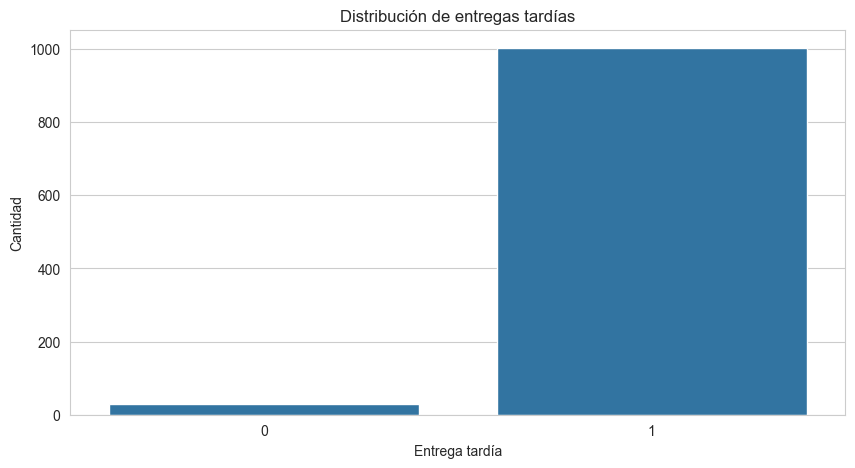

In [5]:

sns.countplot(data=df, x="entrega_tardia")

plt.title("Distribución de entregas tardías")
plt.xlabel("Entrega tardía")
plt.ylabel("Cantidad")

plt.show()



### Análisis

Se observa la distribución general entre entregas normales y entregas tardías. Esta variable representa uno de los principales indicadores operacionales del proyecto y permitirá evaluar posteriormente modelos predictivos.



# Distancia vs Entrega Tardía


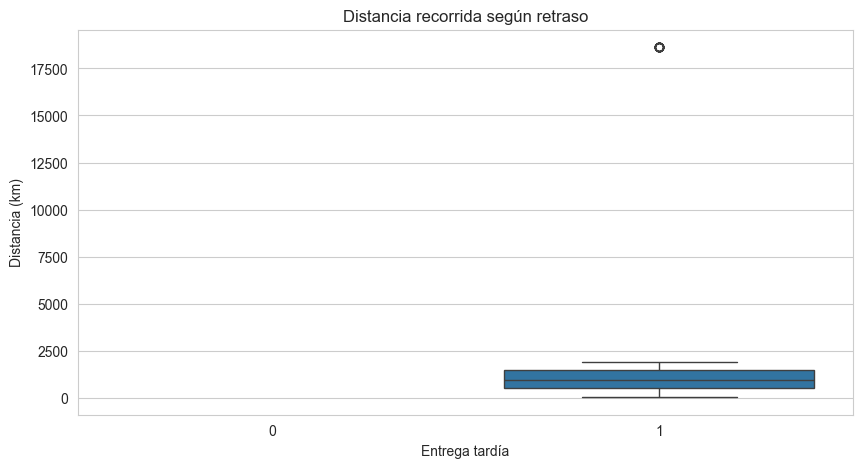

In [6]:

sns.boxplot(data=df, x="entrega_tardia", y="distancia_km")

plt.title("Distancia recorrida según retraso")
plt.xlabel("Entrega tardía")
plt.ylabel("Distancia (km)")

plt.show()



### Análisis

Los envíos con mayores distancias presentan una mayor dispersión en los tiempos de entrega, lo que podría influir directamente en la probabilidad de retraso.



# 🚛 Uso de capacidad del vehículo


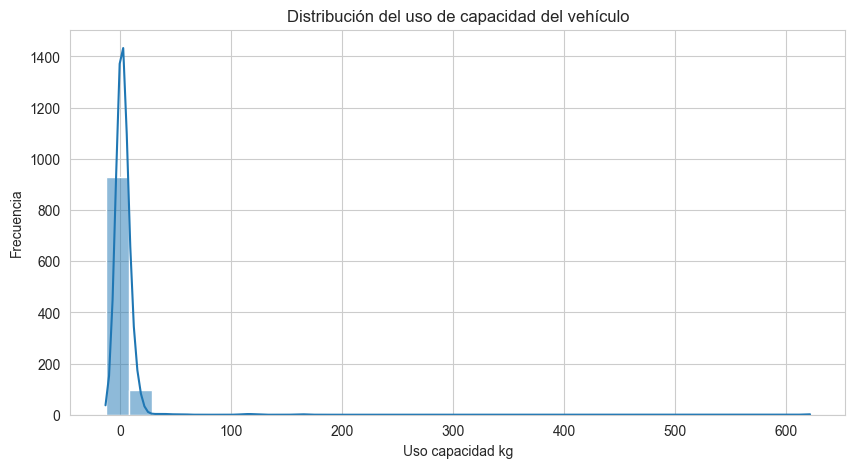

In [7]:

sns.histplot(df["uso_capacidad_kg"], bins=30, kde=True)

plt.title("Distribución del uso de capacidad del vehículo")
plt.xlabel("Uso capacidad kg")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

El uso de capacidad permite identificar qué tan aprovechados se encuentran los vehículos durante las operaciones logísticas.



# ⚠️ Incidencias por tipo de vehículo


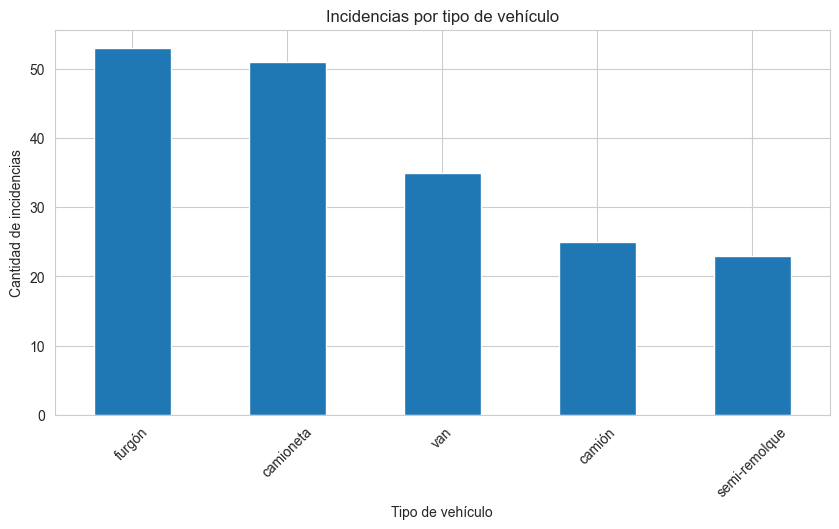

In [8]:

top_incidencias = (
    df.groupby("tipo")["cantidad_incidencias"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_incidencias.plot(kind="bar")

plt.title("Incidencias por tipo de vehículo")
plt.xlabel("Tipo de vehículo")
plt.ylabel("Cantidad de incidencias")

plt.xticks(rotation=45)

plt.show()



### Análisis

Algunos tipos de vehículos concentran una mayor cantidad de incidencias, lo que podría indicar diferencias operacionales o de mantenimiento.



# 🛣️ Rutas con mayor cantidad de retrasos


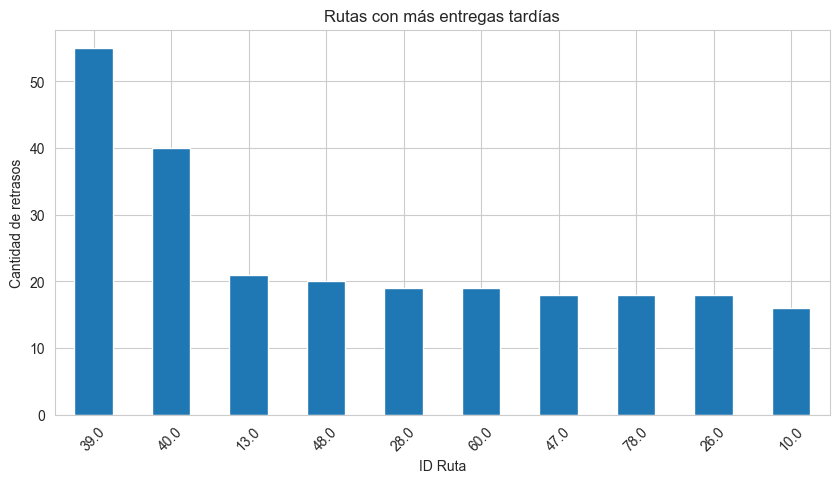

In [9]:

top_rutas = (
    df.groupby("id_ruta")["entrega_tardia"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_rutas.plot(kind="bar")

plt.title("Rutas con más entregas tardías")
plt.xlabel("ID Ruta")
plt.ylabel("Cantidad de retrasos")

plt.xticks(rotation=45)

plt.show()



### Análisis

Existen rutas que presentan una mayor concentración de retrasos, lo cual podría estar asociado a distancia, tráfico o complejidad operacional.



# Costos de incidencias


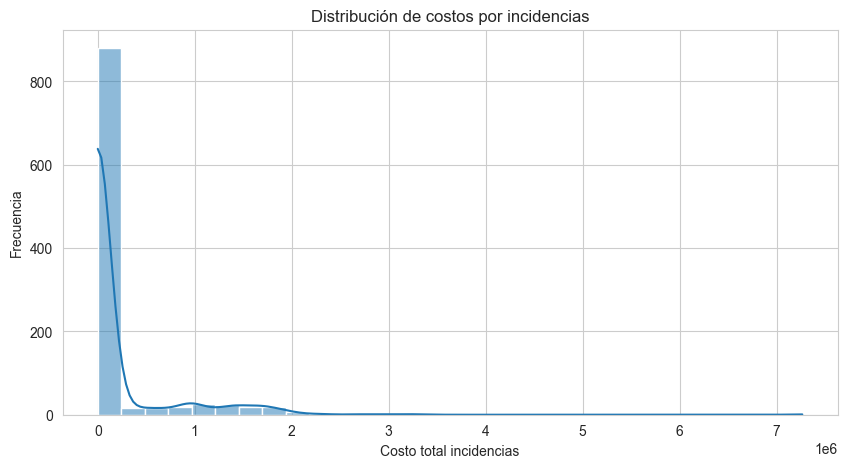

In [10]:

sns.histplot(df["costo_total_incidencias"], bins=30, kde=True)

plt.title("Distribución de costos por incidencias")
plt.xlabel("Costo total incidencias")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

La mayoría de los envíos presentan costos bajos asociados a incidencias, aunque existen algunos casos extremos con impactos considerablemente mayores.



# 📈 Correlación entre variables numéricas


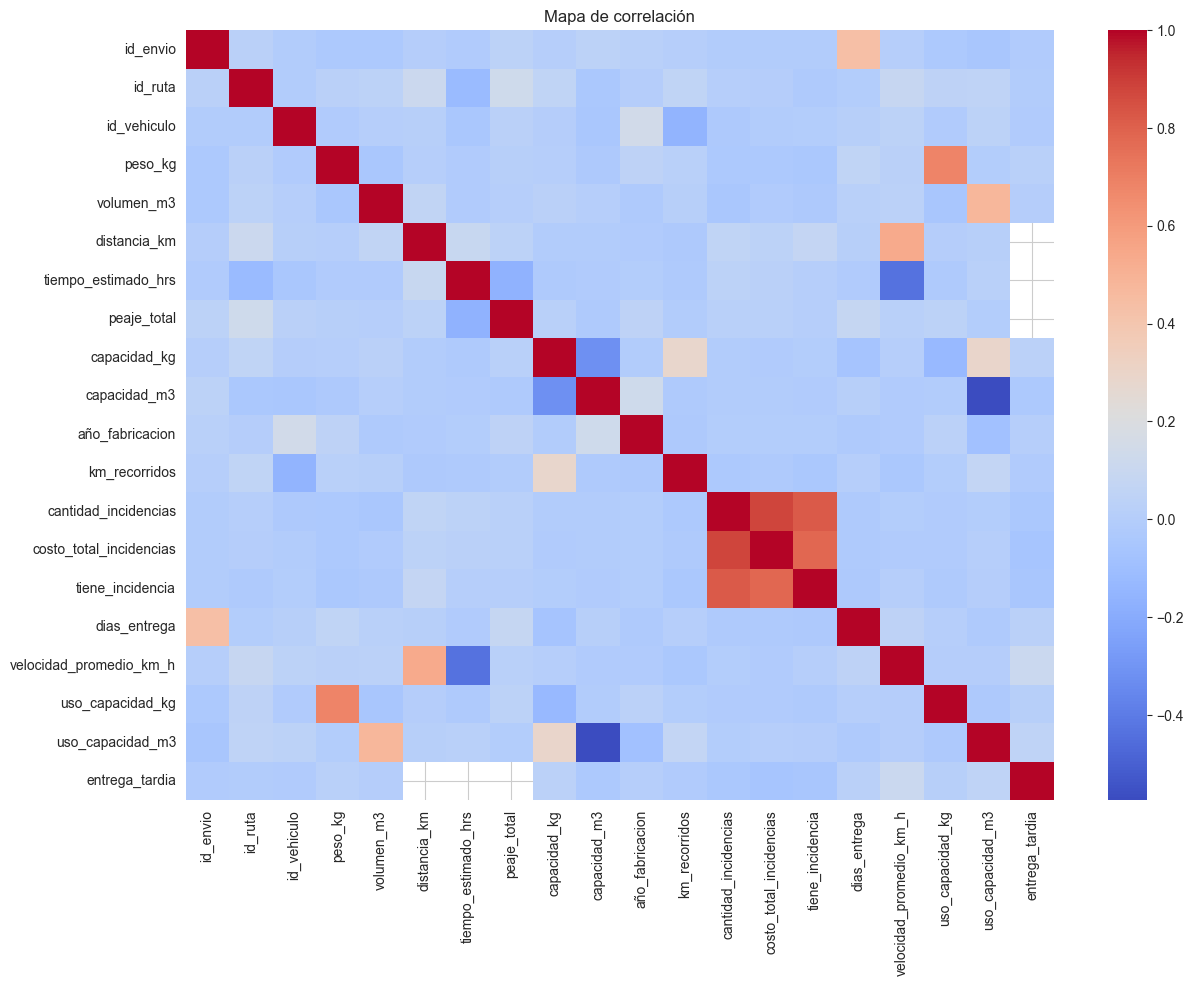

In [11]:

columnas_numericas = df.select_dtypes(include=np.number)

corr = columnas_numericas.corr()

plt.figure(figsize=(14,10))

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Mapa de correlación")

plt.show()



### Análisis

El mapa de correlación permite identificar relaciones relevantes entre variables numéricas y detectar posibles variables influyentes para los modelos predictivos.



#  Velocidad promedio vs entrega tardía


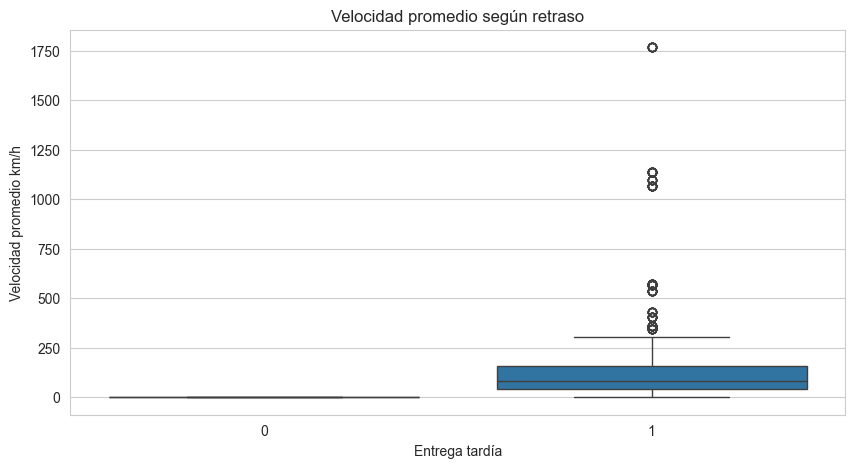

In [12]:

sns.boxplot(data=df, x="entrega_tardia", y="velocidad_promedio_km_h")

plt.title("Velocidad promedio según retraso")
plt.xlabel("Entrega tardía")
plt.ylabel("Velocidad promedio km/h")

plt.show()



### Análisis

La velocidad promedio puede influir directamente en los tiempos de entrega y ayudar a explicar diferencias entre envíos normales y tardíos.



#  Conclusiones Generales

- Se identificaron rutas con mayor concentración de retrasos.
- Existen diferencias operacionales entre tipos de vehículos.
- La distancia recorrida parece influir en los tiempos de entrega.
- Algunas incidencias generan impactos económicos importantes.
- Las variables derivadas creadas en Kedro permiten realizar análisis más profundos y preparar el dataset para Machine Learning.


In [14]:
# ============================================================
# IMPORTACIONES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# CARGAR DATASET
# ============================================================

df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

# ============================================================
# TARGET CLASIFICACIÓN
# ============================================================

percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

# ============================================================
# VARIABLES
# ============================================================

variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [v for v in variables_base if v in df.columns]

# ============================================================
# PREPROCESADOR
# ============================================================

X_temp = df[variables_modelo]

variables_numericas = X_temp.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X_temp.select_dtypes(exclude=np.number).columns.tolist()

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])

# ============================================================
# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================
# ============================================================

print("="*70)
print("RANDOM FOREST CLASSIFIER")
print("="*70)

X_clf = df[variables_modelo]
y_clf = df["riesgo_operacional_alto"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

pipeline_clf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(random_state=42))
])

parametros_clf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf": [1, 2]
}

grid_clf = GridSearchCV(
    pipeline_clf,
    parametros_clf,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_clf.fit(X_train_clf, y_train_clf)

print("\nMEJORES PARÁMETROS:")
print(grid_clf.best_params_)

print("\nMEJOR SCORE CV:")
print(grid_clf.best_score_)

mejor_clf = grid_clf.best_estimator_

y_pred_clf = mejor_clf.predict(X_test_clf)

print("\nMÉTRICAS TEST:")

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall:", recall_score(y_test_clf, y_pred_clf))
print("F1:", f1_score(y_test_clf, y_pred_clf))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test_clf, y_pred_clf))

# ============================================================
# ============================================================
# RANDOM FOREST REGRESSOR
# ============================================================
# ============================================================

print("\n\n")
print("="*70)
print("RANDOM FOREST REGRESSOR")
print("="*70)

datos_reg = df[variables_modelo + ["riesgo_operacional"]].dropna()

X_reg = datos_reg[variables_modelo]
y_reg = datos_reg["riesgo_operacional"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

pipeline_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestRegressor(random_state=42))
])

parametros_reg = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf": [1, 2]
}

grid_reg = GridSearchCV(
    pipeline_reg,
    parametros_reg,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print("\nMEJORES PARÁMETROS:")
print(grid_reg.best_params_)

print("\nMEJOR SCORE CV:")
print(grid_reg.best_score_)

mejor_reg = grid_reg.best_estimator_

y_pred_reg = mejor_reg.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("\nMÉTRICAS TEST:")

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", rmse)
print("R2:", r2_score(y_test_reg, y_pred_reg))

RANDOM FOREST CLASSIFIER

MEJORES PARÁMETROS:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

MEJOR SCORE CV:
0.9325552932948685

MÉTRICAS TEST:
Accuracy: 0.985
Balanced Accuracy: 0.9831734018110556
Precision: 0.96
Recall: 0.9795918367346939
F1: 0.9696969696969697

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       151
           1       0.96      0.98      0.97        49

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200




RANDOM FOREST REGRESSOR

MEJORES PARÁMETROS:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}

MEJOR SCORE CV:
-290.806335720596

MÉTRICAS TEST:
MAE: 59.07308713997237
RMSE: 131.48478380828553
R2: 0.9948292413204362


In [15]:
# ============================================================
# INSTALAR OPTUNA
# ============================================================

!pip install optuna -q

# ============================================================
# IMPORTACIONES
# ============================================================

import optuna
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# CARGAR DATASET
# ============================================================

df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

# ============================================================
# TARGET CLASIFICACIÓN
# ============================================================

percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

# ============================================================
# VARIABLES
# ============================================================

variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [v for v in variables_base if v in df.columns]

# ============================================================
# PREPROCESADOR
# ============================================================

X_temp = df[variables_modelo]

variables_numericas = X_temp.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X_temp.select_dtypes(exclude=np.number).columns.tolist()

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])

# ============================================================
# ============================================================
# OPTUNA - CLASIFICACIÓN
# ============================================================
# ============================================================

print("="*70)
print("OPTUNA - RANDOM FOREST CLASSIFIER")
print("="*70)

X_clf = df[variables_modelo]
y_clf = df["riesgo_operacional_alto"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

def objetivo_clf(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 4, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    modelo = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train_clf, y_train_clf)

    y_pred = pipeline.predict(X_test_clf)

    return f1_score(y_test_clf, y_pred)

study_clf = optuna.create_study(direction="maximize")

study_clf.optimize(objetivo_clf, n_trials=20)

print("\nMEJORES PARÁMETROS:")
print(study_clf.best_params)

print("\nMEJOR F1:")
print(study_clf.best_value)

# Modelo final clasificación
mejor_modelo_clf = RandomForestClassifier(
    **study_clf.best_params,
    random_state=42
)

pipeline_final_clf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", mejor_modelo_clf)
])

pipeline_final_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = pipeline_final_clf.predict(X_test_clf)

print("\nMÉTRICAS FINALES:")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall:", recall_score(y_test_clf, y_pred_clf))
print("F1:", f1_score(y_test_clf, y_pred_clf))

# ============================================================
# ============================================================
# OPTUNA - REGRESIÓN
# ============================================================
# ============================================================

print("\n\n")
print("="*70)
print("OPTUNA - RANDOM FOREST REGRESSOR")
print("="*70)

datos_reg = df[variables_modelo + ["riesgo_operacional"]].dropna()

X_reg = datos_reg[variables_modelo]
y_reg = datos_reg["riesgo_operacional"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

def objetivo_reg(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 4, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    modelo = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train_reg, y_train_reg)

    y_pred = pipeline.predict(X_test_reg)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    return rmse

study_reg = optuna.create_study(direction="minimize")

study_reg.optimize(objetivo_reg, n_trials=20)

print("\nMEJORES PARÁMETROS:")
print(study_reg.best_params)

print("\nMEJOR RMSE:")
print(study_reg.best_value)

# Modelo final regresión
mejor_modelo_reg = RandomForestRegressor(
    **study_reg.best_params,
    random_state=42
)

pipeline_final_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", mejor_modelo_reg)
])

pipeline_final_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = pipeline_final_reg.predict(X_test_reg)

rmse_final = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("\nMÉTRICAS FINALES:")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", rmse_final)
print("R2:", r2_score(y_test_reg, y_pred_reg))


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[I 2026-05-14 16:07:51,319] A new study created in memory with name: no-name-878bcd55-37a6-45a4-bbe1-ed632caf25c5


OPTUNA - RANDOM FOREST CLASSIFIER


[I 2026-05-14 16:07:52,166] Trial 0 finished with value: 0.9591836734693877 and parameters: {'n_estimators': 214, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.9591836734693877.
[I 2026-05-14 16:07:53,391] Trial 1 finished with value: 0.9375 and parameters: {'n_estimators': 292, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9591836734693877.
[I 2026-05-14 16:07:53,947] Trial 2 finished with value: 0.9484536082474226 and parameters: {'n_estimators': 123, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9591836734693877.
[I 2026-05-14 16:07:54,695] Trial 3 finished with value: 0.96 and parameters: {'n_estimators': 172, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.96.
[I 2026-05-14 16:07:55,692] Trial 4 finished with value: 0.9484536082474226 and parameters: {'n_estimators': 233, 'max_depth': 10, 'mi


MEJORES PARÁMETROS:
{'n_estimators': 258, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2}

MEJOR F1:
0.9696969696969697


[I 2026-05-14 16:08:07,826] A new study created in memory with name: no-name-c8c30fe7-1961-42cc-a30d-597711b41a2e



MÉTRICAS FINALES:
Accuracy: 0.985
Balanced Accuracy: 0.9831734018110556
Precision: 0.96
Recall: 0.9795918367346939
F1: 0.9696969696969697



OPTUNA - RANDOM FOREST REGRESSOR


[I 2026-05-14 16:08:10,903] Trial 0 finished with value: 132.03033726458725 and parameters: {'n_estimators': 165, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 132.03033726458725.
[I 2026-05-14 16:08:12,260] Trial 1 finished with value: 283.634169470705 and parameters: {'n_estimators': 157, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 0 with value: 132.03033726458725.
[I 2026-05-14 16:08:15,587] Trial 2 finished with value: 139.66138411300557 and parameters: {'n_estimators': 223, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 132.03033726458725.
[I 2026-05-14 16:08:20,051] Trial 3 finished with value: 207.29866568417984 and parameters: {'n_estimators': 279, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 0 with value: 132.03033726458725.
[I 2026-05-14 16:08:23,160] Trial 4 finished with value: 232.15856381106275 and parameters: {'n_


MEJORES PARÁMETROS:
{'n_estimators': 273, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 1}

MEJOR RMSE:
110.3514798831509

MÉTRICAS FINALES:
MAE: 54.62218378820464
RMSE: 110.3514798831509
R2: 0.9963578351413074
